In [2]:
!pip install pulp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 39.5 MB/s eta 0:00:00


In [94]:
import gymnasium as gym
from gymnasium import spaces
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pulp import LpProblem, LpMaximize, LpVariable, lpSum, value

class BaselineModels():
  def __init__(self, data, num_days):
    super(BaselineModels, self).__init__()
    # no of hours to simulate
    self.num_hours = 24 * num_days
    self.current_hour = 0

    # store all necessary data for Rye Microgrid
    self.data = data

    # setup battery
    self.battery_max = 100
    self.battery_power = 0.5 * self.battery_max
    self.max_discharge = 10
    self.max_charge = 10

    #left over load after renewable energy has been consumed --> positive means
    #not all consumption is satisfied, negative means extra energy.
    self.load=(np.array(self.data['consumption'])[:self.num_hours]
              -np.array(self.data['pv_production'])[:self.num_hours]
              -np.array(self.data['wind_production'])[:self.num_hours])

    #hourly price
    self.price=np.array(self.data['spot_market_price'])[:self.num_hours]

  def step(self, action):
        """
        Actions:
        0 = Charge battery, 1 = Discharge battery,
        2 = Buy from grid, 3 = Sell to grid
        """
        reward = 0
        load = self.load[self.current_hour]

        if action == 0:  # Charge
            charge_amount = min(self.max_charge, -load if load < 0 else 0)
            self.battery_power = min(self.battery_max, self.battery_power + charge_amount)
            reward = 0

        elif action == 1:  # Discharge
            discharge_amount = min(self.max_discharge, load if load > 0 else 0)
            self.battery_power = max(0, self.battery_power - discharge_amount)
            reward = 0

        elif action == 2:  # Buy
            reward = -load * self.price[self.current_hour] if load > 0 else 0

        elif action == 3:  # Sell
            reward = -load * self.price[self.current_hour] if load < 0 else 0

        self.current_hour += 1
        done = self.current_hour >= self.num_hours
        return reward, done



  def reset(self):
    self.current_hour=0
    self.battery_power=0.5*self.battery_max

  def sequence_of_operations(self, visualization=False, full_outputs=False):
    rewards=[]
    actions=[]
    charge=[]

    self.reset()
    done = False
    while not done:
      load = self.load[self.current_hour]

      if load <= 0:
        #Sell
        if self.battery_power == self.battery_max:
          action = 3
        #Charge
        else: action = 0
      else:
        #Discharge
        if self.battery_power * self.battery_max > load and self.max_discharge>load:
          action = 1
        #Buy
        else:
            action = 2

      actions.append(action)
      reward, done=self.step(action)
      rewards.append(reward)
      charge.append(self.battery_power)

    if visualization:
      self.visualize("Sequence of Operations", actions, rewards, charge)
    if full_outputs:
      return sum(rewards), actions, rewards, charge
    else: return float(sum(rewards))



  def milp_optimize(self, visualization=False, full_outputs=False):
    actions = []
    rewards = []
    battery = []

    # Calculate number of weeks
    hours_per_week = 24 * 7
    num_iterations = (self.num_hours + hours_per_week - 1) // hours_per_week

    self.reset()  # Initialize battery state

    for week in range(num_iterations):

        prob = LpProblem(f"MILP_Week_{week}", LpMaximize)


        start_idx = week * hours_per_week
        end_idx = min((week + 1) * hours_per_week, self.num_hours)
        iter_price = self.price[start_idx:end_idx]
        iter_load = self.load[start_idx:end_idx]
        T = len(iter_price)

        if T == 0:
            continue

        x_c = iter_price
        y_c = [-x for x in iter_price]

        # Define variables
        x = {t: LpVariable(f"x_{t}", lowBound=0) for t in range(T)}  # Sell
        xb = {t: LpVariable(f"xb_{t}", cat="Binary") for t in range(T)}
        xa = {t: LpVariable(f"xa_{t}", lowBound=0) for t in range(T)}

        y = {t: LpVariable(f"y_{t}", lowBound=0) for t in range(T)}  # Buy
        yb = {t: LpVariable(f"yb_{t}", cat="Binary") for t in range(T)}
        ya = {t: LpVariable(f"ya_{t}", lowBound=0) for t in range(T)}

        z = {t: LpVariable(f"z_{t}", 0, self.max_charge) for t in range(T)}  # Charge
        zb = {t: LpVariable(f"zb_{t}", cat="Binary") for t in range(T)}
        za = {t: LpVariable(f"za_{t}", lowBound=0) for t in range(T)}

        w = {t: LpVariable(f"w_{t}", 0, self.max_discharge) for t in range(T)}  # Discharge
        wb = {t: LpVariable(f"wb_{t}", cat="Binary") for t in range(T)}
        wa = {t: LpVariable(f"wa_{t}", lowBound=0) for t in range(T)}

        C = {t: LpVariable(f"c_{t}", 0.2*self.battery_max, self.battery_max) for t in range(T)}  # Battery

        M = max(self.battery_max, max(abs(min(iter_load)), max(iter_load))) * 2

        # Objective
        prob += lpSum(x_c[t] * xa[t] + y_c[t] * ya[t] for t in range(T))

        # Constraints
        prob += C[0] == self.battery_power

        for t in range(T):

            prob += -xa[t] + ya[t] - za[t] + wa[t] == iter_load[t]

            prob += xb[t] + yb[t] + zb[t] + wb[t] <= 1

            prob += C[t] <= self.battery_max
            prob += C[t] >= 0

            # State of charge
            if t > 0:
                prob += C[t] == C[t-1] + za[t-1] - wa[t-1]

            # Linearization constraints
            for var, bin_var, act_var in [(x, xb, xa), (y, yb, ya), (z, zb, za), (w, wb, wa)]:
                prob += act_var[t] <= var[t]
                prob += act_var[t] >= var[t] - M * (1 - bin_var[t])
                prob += act_var[t] <= M * bin_var[t]

        # Solve
        status = prob.solve()
        if status != 1:  # Check for optimal solution
            print(f"Warning: Week {week} optimization failed with status {status}")
            continue

        # Extract results
        week_actions = []
        for t in range(T):
            if value(zb[t]) >= 0.99:
                week_actions.append(0)  # Charge
            elif value(wb[t]) >= 0.99:
                week_actions.append(1)  # Discharge
            elif value(yb[t]) >= 0.99:
                week_actions.append(2)  # Buy
            elif value(xb[t]) >= 0.99:
                week_actions.append(3)  # Sell
            else:
                week_actions.append(4)  # Do nothing

        # Apply actions and track results
        for action in week_actions:
            reward, done = self.step(action)
            actions.append(action)
            rewards.append(reward)
            battery.append(self.battery_power)  # Use actual battery state
            if done:
                break

        # Update initial state for next iteration
        if T > 0 and value(C[T-1]) is not None:
            self.battery_power = value(C[T-1])

    if visualization:
        self.visualize("MILP", actions, rewards, battery)

    if full_outputs:
        return sum(rewards), actions, rewards, battery
    return float(sum(rewards))

  def visualize(self, baseline, actions, rewards, battery_power):
    print(baseline)

    time_steps = np.arange(len(rewards))
    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.set_xlabel("Time Step")
    ax1.set_ylabel("Battery Charge", color='tab:blue')
    ax1.plot(time_steps, battery_power, label='Battery Charge', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    ax2 = ax1.twinx()
    ax2.set_ylabel("Reward", color='tab:red')
    ax2.plot(time_steps, rewards, label='Reward', color='tab:red', linestyle='dashed')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    fig.tight_layout()
    plt.show()

    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.set_xlabel("Time Step")
    ax1.set_ylabel("Actions", color='tab:blue')
    ax1.plot(time_steps, actions, 'o-', label='Actions', color='tab:purple')
    ax1.tick_params(axis='y', labelcolor='tab:purple')

    fig.tight_layout()
    plt.show()


MILP


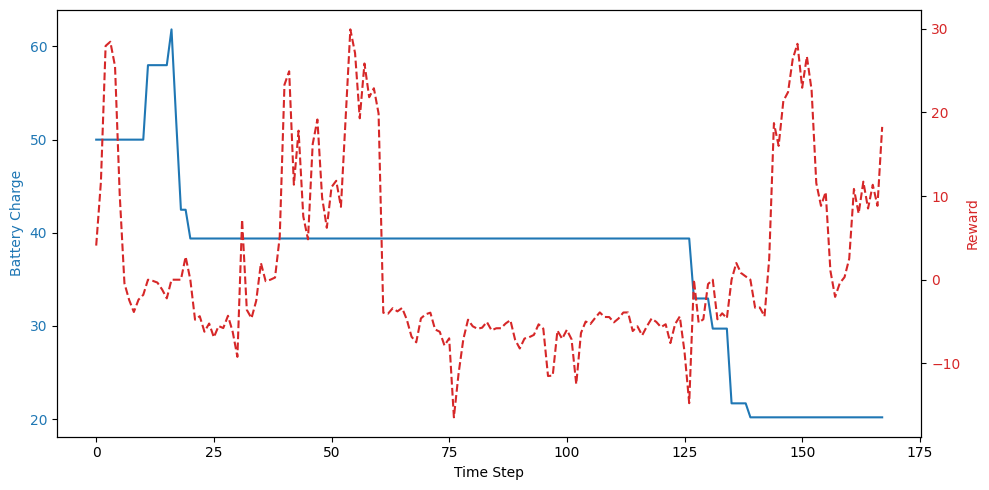

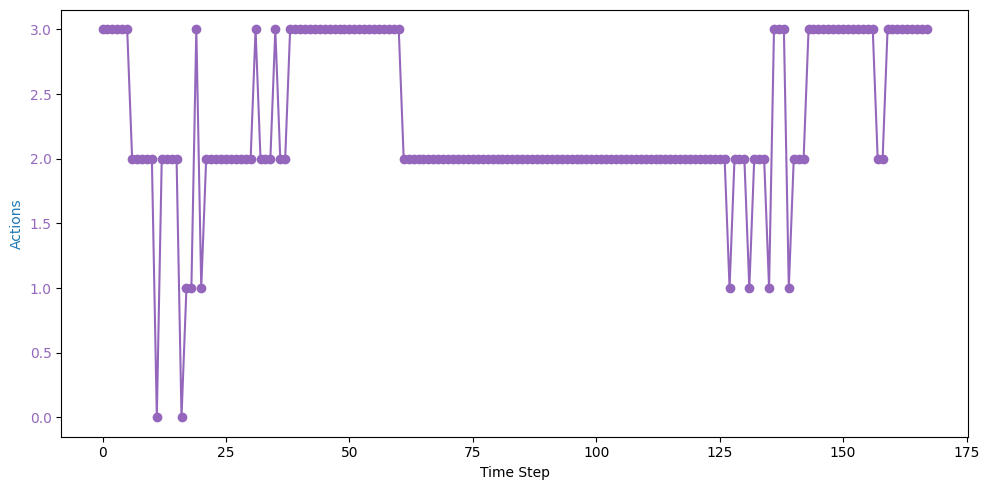

273.13322466709275
Sequence of Operations


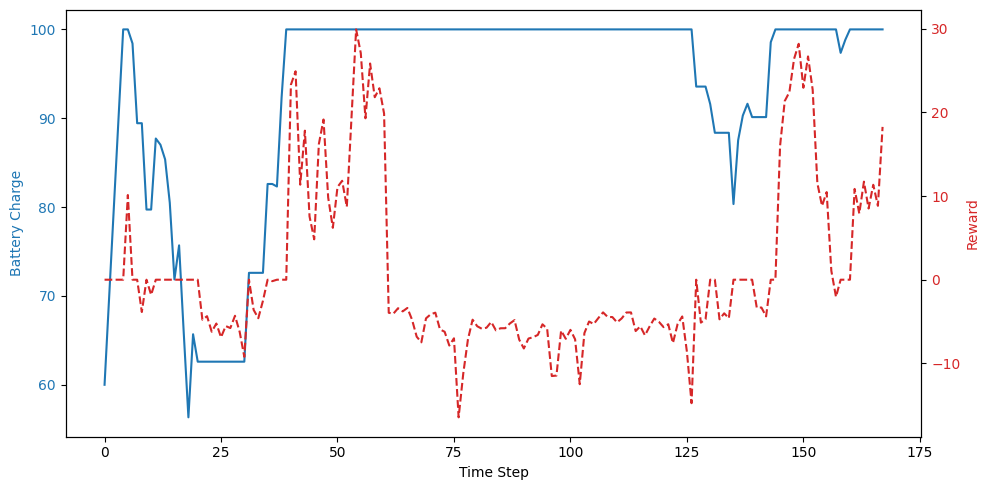

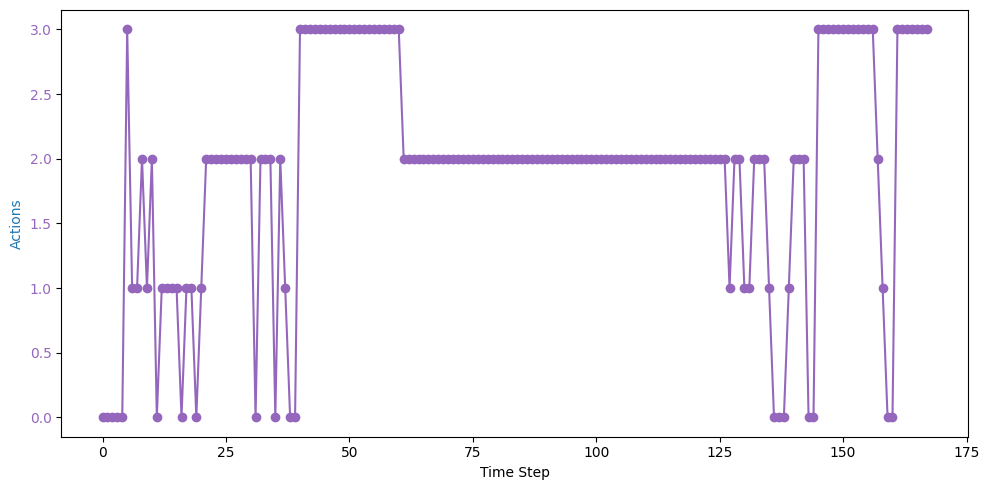

140.9226061841875


In [97]:
data = pd.read_csv("train.csv")
baselines=BaselineModels(data, 7)
print(baselines.milp_optimize(visualization=True))
print(baselines.sequence_of_operations(visualization=True))